In [1]:
import numpy as np
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, auc
from sklearn import metrics
import matplotlib.pyplot as plt
import seaborn as sns

#STRUGGLING TO UNDERSTAND DATA PROPERLY


In [2]:
colnames = ['A1', 'A2', 'A3', 'A4', 'A5', 'A6', 'A7', 'A8', 'A9', 'A10', 'A11', 'A12','A13', 'A14', 'A15','A16', 'A17', 'A18', 'A19', 'A20', 'A21', 'A22', 'A23']
psons_df = pd.read_csv("parkinsons.data",names=colnames)
psons_df.head()


,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,...,A14,A15,A16,A17,A18,A19,A20,A21,A22,A23
name,MDVP:Fo(Hz),MDVP:Fhi(Hz),MDVP:Flo(Hz),MDVP:Jitter(%),MDVP:Jitter(Abs),MDVP:RAP,MDVP:PPQ,Jitter:DDP,MDVP:Shimmer,MDVP:Shimmer(dB),...,Shimmer:DDA,NHR,HNR,status,RPDE,DFA,spread1,spread2,D2,PPE
phon_R01_S01_1,119.99200,157.30200,74.99700,0.00784,0.00007,0.00370,0.00554,0.01109,0.04374,0.42600,...,0.06545,0.02211,21.03300,1,0.414783,0.815285,-4.813031,0.266482,2.301442,0.284654
phon_R01_S01_2,122.40000,148.65000,113.81900,0.00968,0.00008,0.00465,0.00696,0.01394,0.06134,0.62600,...,0.09403,0.01929,19.08500,1,0.458359,0.819521,-4.075192,0.335590,2.486855,0.368674
phon_R01_S01_3,116.68200,131.11100,111.55500,0.01050,0.00009,0.00544,0.00781,0.01633,0.05233,0.48200,...,0.08270,0.01309,20.65100,1,0.429895,0.825288,-4.443179,0.311173,2.342259,0.332634
phon_R01_S01_4,116.67600,137.87100,111.36600,0.00997,0.00009,0.00502,0.00698,0.01505,0.05492,0.51700,...,0.08771,0.01353,20.64400,1,0.434969,0.819235,-4.117501,0.334147,2.405554,0.368975


In [24]:
psons1_df = psons_df.drop(['name'], axis=0)
psons1_df

,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,...,A14,A15,A16,A17,A18,A19,A20,A21,A22,A23
phon_R01_S01_1,119.99200,157.30200,74.99700,0.00784,0.00007,0.00370,0.00554,0.01109,0.04374,0.42600,...,0.06545,0.02211,21.03300,1,0.414783,0.815285,-4.813031,0.266482,2.301442,0.284654
phon_R01_S01_2,122.40000,148.65000,113.81900,0.00968,0.00008,0.00465,0.00696,0.01394,0.06134,0.62600,...,0.09403,0.01929,19.08500,1,0.458359,0.819521,-4.075192,0.335590,2.486855,0.368674
phon_R01_S01_3,116.68200,131.11100,111.55500,0.01050,0.00009,0.00544,0.00781,0.01633,0.05233,0.48200,...,0.08270,0.01309,20.65100,1,0.429895,0.825288,-4.443179,0.311173,2.342259,0.332634
phon_R01_S01_4,116.67600,137.87100,111.36600,0.00997,0.00009,0.00502,0.00698,0.01505,0.05492,0.51700,...,0.08771,0.01353,20.64400,1,0.434969,0.819235,-4.117501,0.334147,2.405554,0.368975
phon_R01_S01_5,116.01400,141.78100,110.65500,0.01284,0.00011,0.00655,0.00908,0.01966,0.06425,0.58400,...,0.10470,0.01767,19.64900,1,0.417356,0.823484,-3.747787,0.234513,2.332180,0.410335
phon_R01_S01_6,120.55200,131.16200,113.78700,0.00968,0.00008,0.00463,0.00750,0.01388,0.04701,0.45600,...,0.06985,0.01222,21.37800,1,0.415564,0.825069,-4.242867,0.299111,2.187560,0.357775
phon_R01_S02_1,120.26700,137.24400,114.82000,0.00333,0.00003,0.00155,0.00202,0.00466,0.01608,0.14000,...,0.02337,0.00607,24.88600,1,0.596040,0.764112,-5.634322,0.257682,1.854785,0.211756
phon_R01_S02_2,107.33200,113.84000,104.31500,0.00290,0.00003,0.00144,0.00182,0.00431,0.01567,0.13400,...,0.02487,0.00344,26.89200,1,0.637420,0.763262,-6.167603,0.183721,2.064693,0.163755
phon_R01_S02_3,95.73000,132.06800,91.75400,0.00551,0.00006,0.00293,0.00332,0.00880,0.02093,0.19100,...,0.03218,0.01070,21.81200,1,0.615551,0.773587,-5.498678,0.327769,2.322511,0.231571
phon_R01_S02_4,95.05600,120.10300,91.22600,0.00532,0.00006,0.00268,0.00332,0.00803,0.02838,0.25500,...,0.04324,0.01022,21.86200,1,0.547037,0.798463,-5.011879,0.325996,2.432792,0.271362


In [8]:
psons1_df.max()

A1      98.804000
A2     592.030000
A3      99.923000
A4       0.033160
A5       0.000260
A6       0.021440
A7       0.019580
A8       0.064330
A9       0.119080
A10      1.302000
A11      0.056470
A12      0.079400
A13      0.137780
A14      0.169420
A15      0.314820
A16      9.449000
A17      1.000000
A18      0.685151
A19      0.825288
A20     -7.964984
A21      0.450493
A22      3.671155
A23      0.527367
dtype: float64

In [9]:
psons1_df.describe()

,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,...,A14,A15,A16,A17,A18,A19,A20,A21,A22,A23
count,195,195,195,195,195,195,195,195,195,195,...,195,195,195,195,195,195,195,195,195,195
unique,195,195,195,173,20,155,165,180,188,149,...,189,185,195,2,195,195,195,194,195,195
top,148.27200,241.35000,89.48800,0.00369,0.00003,0.00169,0.00332,0.00507,0.01503,0.15400,...,0.01898,0.00476,23.21600,1,0.491345,0.686080,-5.391029,0.210279,2.095237,0.112856
freq,1,1,1,3,46,5,4,3,2,5,...,2,2,1,147,1,1,1,2,1,1


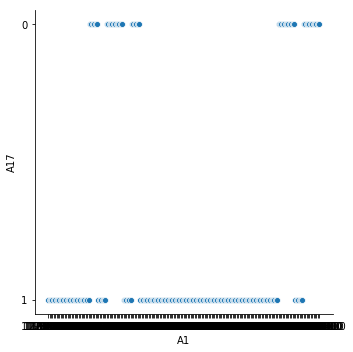

In [22]:
sns.relplot(x="A1", y="A17", data=psons1_df);

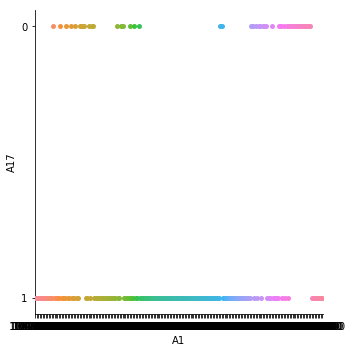

In [23]:
sns.catplot(x="A1", y="A17", data=psons1_df);

C:\Users\Rahul\Anaconda3\lib\site-packages\matplotlib\image.py:863: UserWarning: Attempting to set identical left==right results
in singular transformations; automatically expanding.
left=-0.5, right=-0.5
  self.axes.set_xlim((xmin, xmax), auto=None)
C:\Users\Rahul\Anaconda3\lib\site-packages\matplotlib\image.py:865: UserWarning: Attempting to set identical bottom==top results
in singular transformations; automatically expanding.
bottom=-0.5, top=-0.5
  self.axes.set_ylim((ymin, ymax), auto=None)


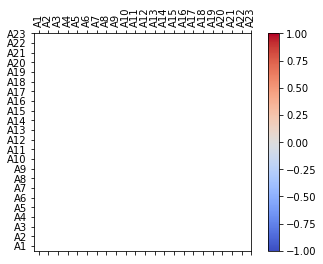

In [26]:


#no correlation between variables?!

corr = psons1_df.corr()
fig = plt.figure()
ax = fig.add_subplot(111)
cax = ax.matshow(corr,cmap='coolwarm', vmin=-1, vmax=1)
fig.colorbar(cax)
ticks = np.arange(0,len(psons1_df.columns),1)
ax.set_xticks(ticks)
plt.xticks(rotation=90)
ax.set_yticks(ticks)
ax.set_xticklabels(psons1_df.columns)
ax.set_yticklabels(psons1_df.columns)
plt.show()


In [34]:
def importdata(): 
    
    colnames = ['A1', 'A2', 'A3', 'A4', 'A5', 'A6', 'A7', 'A8', 'A9', 'A10', 'A11', 'A12','A13', 'A14', 'A15','A16', 'A17', 'A18', 'A19', 'A20', 'A21', 'A22', 'A23']
    psons_df = pd.read_csv("parkinsons.data",names=colnames)

    def splitdataset(psons_df): 
    X=  psons_df.A17
    Y = psons_df.A17 
  
    # Spliting the dataset into train and test 
    X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size = 0.3, random_state = 100) 
      return X, Y, X_train, X_test, y_train, y_test 
      
# Function to perform training with giniIndex. 
def train_using_gini(X_train, X_test, y_train): 
  
    # Creating the classifier object 
    clf_gini = DecisionTreeClassifier(criterion = "gini", 
            random_state = 100,max_depth=3, min_samples_leaf=5) 
  
    # Performing training 
    clf_gini.fit(X_train, y_train) 
    return clf_gini 
      
# Function to perform training with entropy. 
def tarin_using_entropy(X_train, X_test, y_train): 
  
    # Decision tree with entropy 
    clf_entropy = DecisionTreeClassifier( 
            criterion = "entropy", random_state = 100, 
            max_depth = 3, min_samples_leaf = 5) 
  
    # Performing training 
    clf_entropy.fit(X_train, y_train) 
    return clf_entropy 
  
  
# Function to make predictions 
def prediction(X_test, clf_object): 
  
    # Predicton on test with giniIndex 
    y_pred = clf_object.predict(X_test) 
    print("Predicted values:") 
    print(y_pred) 
    return y_pred 
      
# Function to calculate accuracy 
def cal_accuracy(y_test, y_pred): 
      
    print("Confusion Matrix: ", 
        confusion_matrix(y_test, y_pred)) 
      
    print ("Accuracy : ", 
    accuracy_score(y_test,y_pred)*100) 
      
    print("Report : ", 
    classification_report(y_test, y_pred)) 
  
# Driver code 
def main(): 
      
    # Building Phase 
    data = importdata() 
    X, Y, X_train, X_test, y_train, y_test = splitdataset(data) 
    clf_gini = train_using_gini(X_train, X_test, y_train) 
    clf_entropy = tarin_using_entropy(X_train, X_test, y_train) 
      
    # Operational Phase 
    print("Results Using Gini Index:") 
      
    # Prediction using gini 
    y_pred_gini = prediction(X_test, clf_gini) 
    cal_accuracy(y_test, y_pred_gini) 
      
    print("Results Using Entropy:") 
    # Prediction using entropy 
    y_pred_entropy = prediction(X_test, clf_entropy) 
    cal_accuracy(y_test, y_pred_entropy) 
    
if __name__=="__main__": 
    main() 


IndentationError: expected an indented block (<ipython-input-34-8bca1d150a19>, line 7)